# Прогнозирование стоимости жилой недвижимости

## Цель проекта
Разработать ML-модель для прогнозирования стоимости жилого объекта по данным объявления.
Модель должна ускорить первичную оценку предложений и помочь риелторам быстрее находить потенциально выгодные сделки.

## Тип задачи
Задача обучения с учителем — регрессия:
по признакам объявления необходимо предсказать числовую стоимость объекта.

## План работы
1. Загрузить и проверить данные.
2. Очистить целевую переменную и оставить объявления о продаже жилой недвижимости.
3. Провести EDA, обработку пропусков и извлечение признаков.
4. Сравнить baseline, Ridge и CatBoost на валидационной выборке.
5. Обучить выбранную модель на train + validation.
6. Один раз оценить финальную модель на отложенной test-выборке.

In [2]:
import pandas as pd
import numpy as np

RANDOM_STATE = 42

df = pd.read_csv('data.csv')

print('Размер:', df.shape)
display(df.head(3))

Размер: (377185, 18)


,status,private pool,propertyType,street,baths,homeFacts,fireplace,city,schools,sqft,zipcode,beds,state,stories,mls-id,PrivatePool,MlsId,target
0,Active,NaN,Single Family Home,240 Heather Ln,3.5,"{'atAGlanceFacts': [{'factValue': '2019', 'fac...",Gas Logs,Southern Pines,"[{'rating': ['4', '4', '7', 'NR', '4', '7', 'N...",2900,28387,4,NC,NaN,NaN,NaN,611019,"$418,000"
1,for sale,NaN,single-family home,12911 E Heroy Ave,3 Baths,"{'atAGlanceFacts': [{'factValue': '2019', 'fac...",NaN,Spokane Valley,"[{'rating': ['4/10', 'None/10', '4/10'], 'data...","1,947 sqft",99216,3 Beds,WA,2.0,NaN,NaN,201916904,"$310,000"
2,for sale,NaN,single-family home,2005 Westridge Rd,2 Baths,"{'atAGlanceFacts': [{'factValue': '1961', 'fac...",yes,Los Angeles,"[{'rating': ['8/10', '4/10', '8/10'], 'data': ...","3,000 sqft",90049,3 Beds,CA,1.0,NaN,yes,FR19221027,"$2,895,000"


In [3]:
audit = (
    pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        'missing': df.isna().sum(),
        'missing_pct': (df.isna().mean() * 100).round(2),
        'unique': df.nunique(dropna=True)
    })
    .sort_values(['missing_pct', 'unique'], ascending=[False, False])
)

display(audit)

duplicates_count = df.duplicated().sum()

print(f'Полных дубликатов: {duplicates_count:,}')
print(f'Доля полных дубликатов: {duplicates_count / len(df):.3%}')

,dtype,missing,missing_pct,unique
private pool,object,373004,98.89,1
mls-id,object,352243,93.39,24907
PrivatePool,object,336874,89.31,2
fireplace,object,274071,72.66,1652
stories,object,150716,39.96,347
baths,object,106338,28.19,229
beds,object,91282,24.20,1184
MlsId,object,66880,17.73,232944
sqft,object,40577,10.76,25405
status,object,39918,10.58,159


Полных дубликатов: 50
Доля полных дубликатов: 0.013%


## Первичная оценка и удаление дубликатов

На этапе первичного аудита выявлены полные дубликаты строк. Они не несут
дополнительной информации для обучения, поэтому удаляются до формирования
целевой переменной и признаков.

Поле `target` содержит цену в текстовом формате. Перед преобразованием его
в число необходимо проверить примеры значений и отделить объявления о продаже
от объявлений об аренде.

In [4]:
# Удаление полных дубликатов.

rows_before_dedup = len(df)

df = df.drop_duplicates().copy()

rows_after_dedup = len(df)
duplicates_removed = rows_before_dedup - rows_after_dedup

print(f'Размер до удаления дубликатов: {rows_before_dedup:,}')
print(f'Удалено полных дубликатов: {duplicates_removed:,}')
print(f'Размер после удаления дубликатов: {df.shape[0]:,} строк, {df.shape[1]} столбцов')

Размер до удаления дубликатов: 377,185
Удалено полных дубликатов: 50
Размер после удаления дубликатов: 377,135 строк, 18 столбцов


In [5]:
# Предварительный анализ целевой переменной и признака статуса объявления.

target_text = (
    df['target']
    .fillna('')
    .astype(str)
    .str.strip()
    .str.lower()
)

status_text = (
    df['status']
    .fillna('')
    .astype(str)
    .str.strip()
    .str.lower()
)

target_missing_count = df['target'].isna().sum()
target_monthly_rent_count = target_text.str.contains(
    r'/mo\b',
    regex=True
).sum()

rent_status_count = status_text.str.contains(
    r'\brent\b',
    regex=True
).sum()

print(f'Пропусков в target: {target_missing_count:,}')
print(f'Цен с пометкой /mo: {target_monthly_rent_count:,}')
print(f'Объявлений со статусом аренды: {rent_status_count:,}')

Пропусков в target: 2,480
Цен с пометкой /mo: 398
Объявлений со статусом аренды: 412


In [6]:
# Примеры текстового формата целевой переменной.

sample_size = min(20, df['target'].notna().sum())

print('Примеры значений target:')
display(
    df.loc[df['target'].notna(), ['target', 'status']]
    .sample(n=sample_size, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

print('Примеры объявлений, связанных с арендой:')
display(
    df.loc[
        status_text.str.contains(r'\brent\b', regex=True)
        | target_text.str.contains(r'/mo\b', regex=True),
        ['status', 'target']
    ]
    .head(10)
)

Примеры значений target:


,target,status
0,"$69,500",Active
1,"$519,000",for sale
2,"$325,000",for sale
3,"$302,990",Active
4,"$829,000",For sale
5,"$749,888",New construction
6,"$409,999",for sale
7,"$217,580",for sale
8,"$229,000",for sale
9,"$299,000",NaN


Примеры объявлений, связанных с арендой:


,status,target
547,for rent,"$5,500/mo"
609,for rent,"$10,500/mo"
2075,for rent,"$6,390/mo"
3025,for rent,"$1,200/mo"
3645,for rent,"$3,600/mo"
4613,for rent,"$5,500/mo"
5515,for rent,"$1,200/mo"
5873,Apartment for rent,"$1,250"
6837,for rent,"$1,200/mo"
8167,for rent,"$3,250/mo"


### Очистка целевой переменной

Поле `target` содержит цену в текстовом формате, поэтому его необходимо
преобразовать в числовой тип. В данных также есть объявления об аренде:
они определяются по слову `rent` в статусе или по пометке `/mo` в цене.

Для моделирования стоимости продажи исключаются:
- объявления об аренде;
- строки без распознанной цены;
- цены ниже 1 000 долларов.

Целевая переменная сохраняется в столбце `price`. Логарифм `log_price`
будет использоваться как целевая переменная модели, поскольку распределение
цен имеет длинный правый хвост.

In [7]:
# Определение объявлений, относящихся к аренде.

is_rent = (
    status_text.str.contains(r'\brent\b', regex=True)
    | target_text.str.contains(r'/mo\b', regex=True)
)

# Преобразование текстовой цены в число.
# Удаляем валютные символы, разделители тысяч, знак "+" и прочие нечисловые символы.

df['price'] = pd.to_numeric(
    target_text.str.replace(r'[^0-9.]', '', regex=True),
    errors='coerce'
)

# Минимальная допустимая цена продажи.
MIN_SALE_PRICE = 1_000

sales_mask = (
    ~is_rent
    & df['price'].notna()
    & df['price'].ge(MIN_SALE_PRICE)
)

sales_df = df.loc[sales_mask].copy()

print(f'Всего объявлений после удаления дубликатов: {len(df):,}')
print(f'Исключено объявлений об аренде: {is_rent.sum():,}')
print(f'Строк без распознанной цены: {df["price"].isna().sum():,}')
print(f'Строк с ценой ниже ${MIN_SALE_PRICE:,}: {(df["price"].lt(MIN_SALE_PRICE)).sum():,}')
print(f'Объявлений о продаже для дальнейшего анализа: {len(sales_df):,}')

display(
    sales_df['price']
    .describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
    .to_frame('price')
)

Всего объявлений после удаления дубликатов: 377,135
Исключено объявлений об аренде: 412
Строк без распознанной цены: 2,480
Строк с ценой ниже $1,000: 101
Объявлений о продаже для дальнейшего анализа: 374,167


,price
count,3.741670e+05
mean,6.455644e+05
std,1.842441e+06
min,1.000000e+03
1%,7.500000e+03
5%,3.790000e+04
25%,1.879900e+05
50%,3.200000e+05
75%,5.849000e+05
95%,1.950000e+06


In [8]:
# Проверка нижней и верхней границ целевой переменной.
# Экстремальные значения показываются для ручной проверки, но не удаляются:
# дорогая недвижимость представляет реальный сегмент рынка.

display_columns = [
    'price',
    'propertyType',
    'city',
    'state',
    'zipcode',
    'sqft',
    'beds',
    'baths',
    'status'
]

print('Объекты с минимальными значениями цены:')
display(
    sales_df[display_columns]
    .nsmallest(20, columns='price')
)

print('Объекты с максимальными значениями цены:')
display(
    sales_df[display_columns]
    .nlargest(20, columns='price')
)

Объекты с минимальными значениями цены:


,price,propertyType,city,state,zipcode,sqft,beds,baths,status
1357,1000.0,single-family home,Detroit,MI,48206,"2,544 sqft",6 Beds,2 Baths,foreclosure
1682,1000.0,Single Family,Detroit,MI,48219,"1,572 sqft",4,2.0,NaN
2282,1000.0,single-family home,Detroit,MI,48205,"2,048 sqft",4 Beds,2 Baths,foreclosure
2644,1000.0,single-family home,Detroit,MI,48227,"1,827 sqft",4 Beds,2 Baths,foreclosure
2673,1000.0,NaN,Memphis,TN,38106,NaN,NaN,NaN,Active
2923,1000.0,single-family home,Detroit,MI,48205,921 sqft,3 Beds,NaN,foreclosure
3049,1000.0,single-family home,Detroit,MI,48213,"1,386 sqft",3 Beds,2 Baths,foreclosure
3239,1000.0,single-family home,Detroit,MI,48204,"1,984 sqft",4 Beds,2 Baths,foreclosure
3380,1000.0,NaN,Memphis,TN,38108,NaN,NaN,NaN,Active
3616,1000.0,single-family home,Detroit,MI,48234,687 sqft,3 Beds,NaN,foreclosure


Объекты с максимальными значениями цены:


,price,propertyType,city,state,zipcode,sqft,beds,baths,status
132425,195000000.0,Single Family,Los Angeles,CA,90077,--,11,18.0,For sale
143528,165000000.0,single-family home,Beverly Hills,CA,90210,"28,660 sqft",20 Beds,23 Baths,for sale
285993,165000000.0,Single Family,Beverly Hills,CA,90210,"28,660",20,23.0,For sale
110083,150000000.0,single-family home,Los Angeles,CA,90077,NaN,NaN,NaN,for sale
178931,129000000.0,Single Family,Beverly Hills,CA,90210,"43,000",12,23.0,For sale
119862,115000000.0,Single Family,Los Angeles,CA,90077,"12,201",9,10.0,For sale
294206,115000000.0,single-family home,Los Angeles,CA,90077,"12,201 sqft",9 Beds,10 Baths,for sale
54164,110000000.0,single-family home,Beverly Hills,CA,90210,"38,000 sqft",12 Beds,24 Baths,for sale
354264,110000000.0,lot/land,Beverly Hills,CA,90210,741 sqft,NaN,NaN,for sale
151594,98000000.0,Condo,New York,NY,10016,"19,815",11,14,For sale


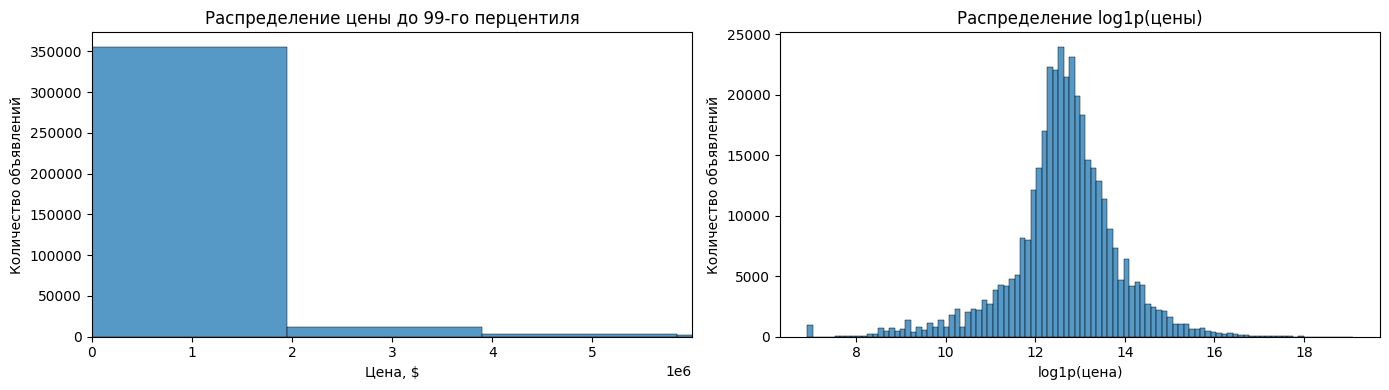

In [9]:
# Анализ распределения целевой переменной.

import matplotlib.pyplot as plt
import seaborn as sns

sales_df['log_price'] = np.log1p(sales_df['price'])

price_p99 = sales_df['price'].quantile(0.99)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 4))

sns.histplot(
    data=sales_df,
    x='price',
    bins=100,
    ax=axes[0]
)
axes[0].set_xlim(0, price_p99)
axes[0].set_title('Распределение цены до 99-го перцентиля')
axes[0].set_xlabel('Цена, $')
axes[0].set_ylabel('Количество объявлений')

sns.histplot(
    data=sales_df,
    x='log_price',
    bins=100,
    ax=axes[1]
)
axes[1].set_title('Распределение log1p(цены)')
axes[1].set_xlabel('log1p(цена)')
axes[1].set_ylabel('Количество объявлений')

plt.tight_layout()
plt.show()

### Извлечение и очистка числовых признаков

Поля `sqft`, `beds`, `baths` и `stories` хранят числовую информацию в разных
текстовых форматах: с единицами измерения, дополнительными пояснениями,
разделителями тысяч и пропусками.

Для каждого поля используется отдельная функция преобразования. Это позволяет
извлекать значения с учётом смысла столбца: площадь определяется по маркеру
`sqft`, количество спален — по `bed` или `bd`, а количество ванных — по
`bath` или `ba`. Значения, не соответствующие физически допустимым диапазонам,
заменяются на пропуски и будут заполнены медианой только на обучающей выборке.

In [13]:
import re


def normalize_numeric_text(value) -> str:
    """Преобразует значение в нормализованную текстовую строку."""
    if pd.isna(value):
        return ''

    return (
        str(value)
        .strip()
        .lower()
        .replace(',', '')
    )


def parse_sqft(value) -> float:
    """Извлекает площадь объекта в квадратных футах."""
    text = normalize_numeric_text(value)

    if text in {'', '--', 'nan', 'none'}:
        return np.nan

    patterns = [
        r'(\d+(?:\.\d+)?)\s*(?:sq\.?\s*ft\.?|sqft)',
        r'(\d+(?:\.\d+)?)\s*$'
    ]

    for pattern in patterns:
        match = re.search(pattern, text)
        if match:
            return float(match.group(1))

    return np.nan


def parse_beds(value) -> float:
    """Извлекает количество спален."""
    text = normalize_numeric_text(value)

    if text in {'', '--', 'nan', 'none', 'studio'}:
        return np.nan

    patterns = [
        r'(\d+(?:\.\d+)?)\s*(?:beds?|bd)\b',
        r'^(\d+(?:\.\d+)?)$'
    ]

    for pattern in patterns:
        match = re.search(pattern, text)
        if match:
            return float(match.group(1))

    return np.nan


def parse_baths(value) -> float:
    """Извлекает количество ванных комнат."""
    text = normalize_numeric_text(value)

    if text in {'', '--', 'nan', 'none'}:
        return np.nan

    patterns = [
        r'(\d+(?:\.\d+)?)\s*(?:baths?|ba)\b',
        r'(?:bathrooms?\s*:?\s*)(\d+(?:\.\d+)?)',
        r'^(\d+(?:\.\d+)?)$'
    ]

    for pattern in patterns:
        match = re.search(pattern, text)
        if match:
            return float(match.group(1))

    return np.nan


def parse_stories(value) -> float:
    """Извлекает количество этажей."""
    text = normalize_numeric_text(value)

    if text in {'', '--', 'nan', 'none'}:
        return np.nan

    patterns = [
        r'(\d+(?:\.\d+)?)\s*(?:stories|story|storeys|storey)\b',
        r'^(\d+(?:\.\d+)?)$'
    ]

    for pattern in patterns:
        match = re.search(pattern, text)
        if match:
            return float(match.group(1))

    return np.nan

In [14]:
# Извлечение числовых признаков из текстовых полей.

sales_df['sqft_num'] = sales_df['sqft'].apply(parse_sqft)
sales_df['beds_num'] = sales_df['beds'].apply(parse_beds)
sales_df['baths_num'] = sales_df['baths'].apply(parse_baths)
sales_df['stories_num'] = sales_df['stories'].apply(parse_stories)

numeric_columns = [
    'sqft_num',
    'beds_num',
    'baths_num',
    'stories_num'
]


def make_numeric_report(frame: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    """Формирует сводную таблицу числовых признаков."""
    return pd.DataFrame({
        'missing_pct': frame[columns].isna().mean().mul(100).round(2),
        'min': frame[columns].min(),
        'median': frame[columns].median(),
        'max': frame[columns].max()
    })


print('Сводка до обработки некорректных значений:')
display(make_numeric_report(sales_df, numeric_columns))

Сводка до обработки некорректных значений:


,missing_pct,min,median,max
sqft_num,10.92,0.0,1800.0,795979430.0
beds_num,29.67,0.0,3.0,144.0
baths_num,28.78,0.0,2.5,5000.0
stories_num,43.62,0.0,2.0,1120.0


In [15]:
# Контроль примеров извлечения значений.
# Он подтверждает, что парсеры корректно обрабатывают разные исходные форматы.

parse_check = sales_df[
    ['sqft', 'sqft_num', 'beds', 'beds_num', 'baths', 'baths_num', 'stories', 'stories_num']
].sample(
    n=min(15, len(sales_df)),
    random_state=RANDOM_STATE
)

display(parse_check)

,sqft,sqft_num,beds,beds_num,baths,baths_num,stories,stories_num
63455,629,629.0,1,1.0,1.0,1.0,NaN,NaN
42624,"2,926",2926.0,3,3.0,3.0,3.0,1.0,1.0
67147,"1,289",1289.0,NaN,NaN,NaN,NaN,NaN,NaN
251662,1716,1716.0,3,3.0,2,2.0,NaN,NaN
354373,"1,930",1930.0,Baths,NaN,Sq. Ft.,NaN,NaN,NaN
368370,"1,635 sqft",1635.0,NaN,NaN,NaN,NaN,1.0,1.0
265594,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
293289,1380,1380.0,2.0,2.0,2.5,2.5,Townhouse,NaN
254408,"Total interior livable area: 4,699 sqft",4699.0,5 bd,5.0,Bathrooms: 5,5.0,NaN,NaN
306623,"3,512",3512.0,4,4.0,4.0,4.0,2.0,2.0


In [16]:
# Физически допустимые интервалы признаков.
# Значения вне диапазонов считаются ошибками формата и заменяются на NaN.

valid_ranges = {
    'sqft_num': (100, 50_000),
    'beds_num': (1, 30),
    'baths_num': (0.5, 30),
    'stories_num': (1, 10)
}

invalid_counts = {}

for column, (lower_bound, upper_bound) in valid_ranges.items():
    invalid_mask = (
        sales_df[column].notna()
        & ~sales_df[column].between(lower_bound, upper_bound)
    )

    invalid_counts[column] = invalid_mask.sum()
    sales_df.loc[invalid_mask, column] = np.nan

invalid_report = (
    pd.Series(invalid_counts, name='invalid_values')
    .to_frame()
)

print('Количество значений, заменённых на NaN:')
display(invalid_report)

print('Сводка после обработки некорректных значений:')
display(make_numeric_report(sales_df, numeric_columns))

Количество значений, заменённых на NaN:


,invalid_values
sqft_num,13027
beds_num,1521
baths_num,18464
stories_num,13273


Сводка после обработки некорректных значений:


,missing_pct,min,median,max
sqft_num,14.40,100.0,1838.0,50000.0
beds_num,30.07,1.0,3.0,30.0
baths_num,33.71,0.5,2.5,30.0
stories_num,47.16,1.0,2.0,10.0


In [17]:
# Проверка минимальных и максимальных допустимых значений после очистки.

inspection_columns = [
    'price',
    'propertyType',
    'city',
    'state',
    'sqft',
    'beds',
    'baths',
    'stories'
]

for column in numeric_columns:
    print(f'\nПроверка границ признака: {column}')

    print('Минимальные значения:')
    display(
        sales_df.loc[
            sales_df[column].notna(),
            [column] + inspection_columns
        ]
        .nsmallest(5, columns=column)
    )

    print('Максимальные значения:')
    display(
        sales_df.loc[
            sales_df[column].notna(),
            [column] + inspection_columns
        ]
        .nlargest(5, columns=column)
    )


Проверка границ признака: sqft_num
Минимальные значения:


,sqft_num,price,propertyType,city,state,sqft,beds,baths,stories
9261,100.0,789000.0,lot/land,Saint Johns,FL,100 sqft,NaN,NaN,NaN
62267,100.0,400000.0,Miscellaneous,Miami,FL,100 sqft,0,NaN,NaN
121653,100.0,700000.0,lot/land,Brooksville,FL,100 sqft,2 Beds,2 Baths,1.0
162864,100.0,20000.0,Single Family Home,Alexandria,VA,100,0,0,1
182169,100.0,401369.0,Single Family,Miami,FL,100 sqft,4,2.0,1.0


Максимальные значения:


,sqft_num,price,propertyType,city,state,sqft,beds,baths,stories
71505,50000.0,225000.0,coop,Brooklyn,NY,"50,000 sqft",NaN,2 Baths,NaN
244441,50000.0,990000.0,Multi-Family Home,Saint Albans Town,VT,50000,NaN,NaN,3
284189,49670.0,5000000.0,multi-family,Brownsville,TX,"49,670 sqft",NaN,NaN,NaN
109722,49660.0,385000.0,coop,Sunnyside,NY,"49,660 sqft",NaN,NaN,6.0
53097,49484.0,85000.0,lot/land,Panama City,FL,"49,484 sqft",NaN,NaN,NaN



Проверка границ признака: beds_num
Минимальные значения:


...

,baths_num,price,propertyType,city,state,sqft,beds,baths,stories
167137,30.0,3750000.0,townhouse,Fort Lauderdale,FL,NaN,34 Beds,30 Baths,2.0
231100,30.0,138000.0,Multi-Family Home,Marshall,MI,2100,4.0,30,2 Story
242978,30.0,3495000.0,multi-family,Van Nuys,CA,"11,180 sqft",26 Beds,30 Baths,2.0
246995,30.0,3750000.0,Townhouse,Dania Beach,FL,--,34,30.0,2
300841,30.0,289900.0,single-family home,Spring Hill,FL,"2,301 sqft",4 Beds,30 Baths,1.0



Проверка границ признака: stories_num
Минимальные значения:


,stories_num,price,propertyType,city,state,sqft,beds,baths,stories
2,1.0,2895000.0,single-family home,Los Angeles,CA,"3,000 sqft",3 Beds,2 Baths,1.0
12,1.0,525000.0,single-family home,Pembroke Pines,FL,"2,839 sqft",4 Beds,3 Baths,1.0
13,1.0,499900.0,Single Family,Eugene,OR,"Total interior livable area: 1,820 sqft",3 bd,Bathrooms: 2,1.0
19,1.0,626000.0,multi-family,Fort Lauderdale,FL,"1,612 sqft",4 Beds,4 Baths,1.0
21,1.0,3500000.0,Single Family,Bend,OR,"Total interior livable area: 5,266 sqft",5 bd,Bathrooms: 5,1.0


Максимальные значения:


,stories_num,price,propertyType,city,state,sqft,beds,baths,stories
13428,10.0,549000.0,Condo,Cincinnati,OH,"1,668",2,2.0,10
24931,10.0,400000.0,coop,Woodside,NY,675 sqft,NaN,NaN,10
30278,10.0,1068000.0,condo,Queens,NY,"1,045 sqft",2 Beds,2 Baths,10
30448,10.0,335000.0,coop,Bronx,NY,650 sqft,NaN,NaN,10
34689,10.0,750000.0,Cooperative,New York,NY,"49,000",1,2,10.0


### Вывод по числовым признакам

Текстовые поля площади, количества спален, ванных комнат и этажей преобразованы
в числовые признаки. До очистки в данных встречались явно некорректные значения,
например чрезвычайно большие площади и количества комнат, возникшие из-за
ошибок исходного формата или неоднозначного текста.

Такие значения заменены на `NaN`, а не удалены вместе со строками. На этапе
обучения модели пропуски будут заполнены медианой на обучающей выборке с помощью
`SimpleImputer`, что предотвращает потерю большого числа объявлений и не приводит
к утечке информации из validation и test-выборок.

### Тип недвижимости

Исходный признак `propertyType` содержит большое число вариантов написания:
синонимы, разные регистры, архитектурные стили и комбинированные типы
объектов. Для уменьшения количества редких категорий и повышения устойчивости
модели значения агрегируются в укрупнённые группы.

Земельные участки (`land`, `lot/land`) не являются жилыми объектами. Их
распределение цен отличается от распределения стоимости домов, поэтому они
исключаются из выборки в соответствии с целью проекта.

In [20]:
# Нормализация исходного признака propertyType.

property_type = (
    sales_df['propertyType']
    .fillna('missing')
    .astype(str)
    .str.strip()
    .str.lower()
)

print(f'Уникальных исходных значений propertyType: {property_type.nunique():,}')

display(
    property_type
    .value_counts()
    .head(30)
    .to_frame('listings')
)

Уникальных исходных значений propertyType: 1,272


,listings
propertyType,
single-family home,91150
single family,61884
condo,42358
missing,34538
single family home,31724
lot/land,20467
townhouse,18297
land,10928
multi-family,7762


In [21]:
def group_property_type(value: str) -> str:
    """Объединяет исходные типы недвижимости в устойчивые группы."""
    text = str(value).strip().lower()

    if text in {'', 'missing', 'nan', 'none'}:
        return 'missing'

    if 'land' in text or 'lot' in text:
        return 'land'

    if 'condo' in text or 'coop' in text or 'co-op' in text:
        return 'condo_coop'

    if 'town' in text or 'row home' in text:
        return 'townhouse'

    if any(token in text for token in ['multi', 'duplex', 'triplex', 'fourplex']):
        return 'multi_family'

    if 'mobile' in text or 'manufactured' in text:
        return 'mobile_manufactured'

    if 'apartment' in text:
        return 'apartment'

    if any(
        token in text
        for token in [
            'single',
            'detached',
            'ranch',
            'colonial',
            'traditional',
            'contemporary',
            'one story',
            'two story'
        ]
    ):
        return 'single_family'

    return 'other'


sales_df['property_group'] = property_type.apply(group_property_type)

property_summary = (
    sales_df
    .groupby('property_group', dropna=False)
    .agg(
        listings=('price', 'size'),
        median_price=('price', 'median'),
        mean_price=('price', 'mean')
    )
    .sort_values('listings', ascending=False)
)

property_summary['share_pct'] = (
    property_summary['listings']
    .div(len(sales_df))
    .mul(100)
    .round(2)
)

display(property_summary)

,listings,median_price,mean_price,share_pct
property_group,,,,
single_family,206426,334990.0,609662.159554,55.17
condo_coop,55142,369900.0,816657.679573,14.74
missing,34662,310000.0,860066.595407,9.26
land,31465,73600.0,316754.857079,8.41
townhouse,18480,319994.0,576174.586472,4.94
multi_family,12549,599000.0,953159.750339,3.35
other,11074,349000.0,637108.126422,2.96
mobile_manufactured,3560,99500.0,125224.073876,0.95
apartment,809,550000.0,962028.862794,0.22


In [22]:
# Земля исключается до обучения модели.
# Количество рассчитывается по property_group, а не по точному исходному тексту.

land_count = sales_df['property_group'].eq('land').sum()
land_share = land_count / len(sales_df) * 100

sales_df = sales_df.loc[
    sales_df['property_group'].ne('land')
].copy()

print(f'Исключено земельных участков: {land_count:,} ({land_share:.2f}%)')
print(f'Размер выборки после исключения земли: {sales_df.shape[0]:,} строк, {sales_df.shape[1]} столбцов')

Исключено земельных участков: 31,465 (8.41%)
Размер выборки после исключения земли: 342,702 строк, 25 столбцов


### Географические признаки

Стоимость недвижимости существенно различается между регионами. Поэтому в
модель будут включены `state`, `city` и `zipcode`. До обучения проверяются
пропуски, количество категорий и распределение объявлений по регионам.

In [24]:
geo_columns = ['state', 'city', 'zipcode']

geo_report = pd.DataFrame({
    'missing': sales_df[geo_columns].isna().sum(),
    'missing_pct': sales_df[geo_columns].isna().mean().mul(100).round(3),
    'unique': sales_df[geo_columns].nunique(dropna=True)
})

display(geo_report)

print('Топ-10 штатов по числу объявлений:')
display(
    sales_df['state']
    .value_counts()
    .head(10)
    .to_frame('listings')
)

print('Топ-10 городов по числу объявлений:')
display(
    sales_df['city']
    .value_counts()
    .head(10)
    .to_frame('listings')
)

,missing,missing_pct,unique
state,0,0.000,38
city,9,0.003,1908
zipcode,0,0.000,4469


Топ-10 штатов по числу объявлений:


,listings
state,
FL,101997
TX,77916
NY,23866
CA,22151
NC,18886
TN,15832
WA,12526
OH,11495
IL,8179


Топ-10 городов по числу объявлений:


,listings
city,
Houston,23278
Miami,15244
San Antonio,15018
Jacksonville,9467
Dallas,8399
Brooklyn,7183
New York,6902
Chicago,6327
Charlotte,6074


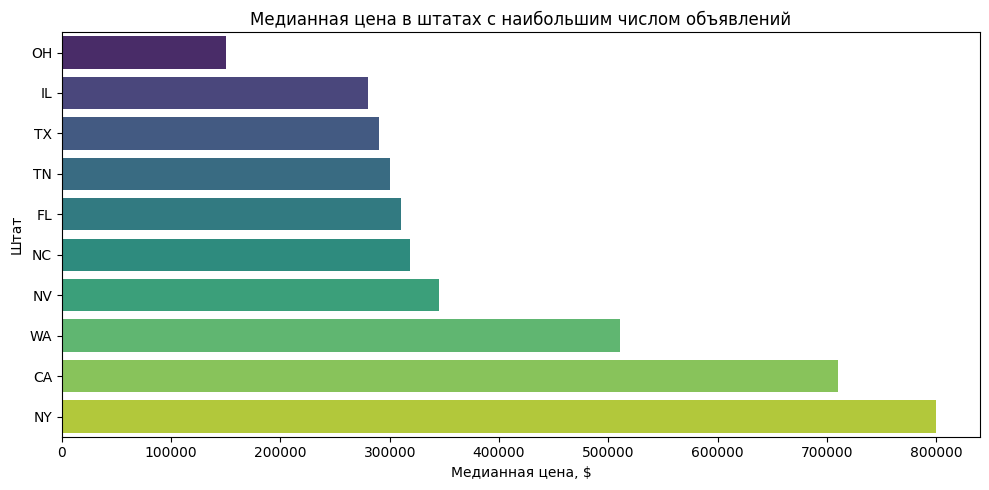

,state,listings,median_price
0,OH,11495,149900.0
1,IL,8179,279900.0
2,TX,77916,290000.0
3,TN,15832,299900.0
4,FL,101997,309900.0
5,NC,18886,319000.0
6,NV,7642,345000.0
7,WA,12526,510990.0
8,CA,22151,710000.0
9,NY,23866,800000.0


In [25]:
# Сравнение медианных цен в штатах с наибольшим числом объявлений.
# Используется медиана, потому что она устойчива к дорогим объектам в хвосте
# распределения цены.

top_states = sales_df['state'].value_counts().head(10).index

state_stats = (
    sales_df.loc[sales_df['state'].isin(top_states)]
    .groupby('state')
    .agg(
        listings=('price', 'size'),
        median_price=('price', 'median')
    )
    .sort_values('median_price')
    .reset_index()
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=state_stats,
    x='median_price',
    y='state',
    hue='state',
    legend=False,
    palette='viridis'
)

plt.title('Медианная цена в штатах с наибольшим числом объявлений')
plt.xlabel('Медианная цена, $')
plt.ylabel('Штат')
plt.tight_layout()
plt.show()

display(state_stats)

### Вывод по типу и географии

Признак `propertyType` был агрегирован в укрупнённые группы, что уменьшает
число редких категорий и сохраняет различия между основными видами жилья.
Земельные участки исключены, так как не относятся к задаче оценки жилой
недвижимости.

Географические признаки заполнены почти полностью и содержат информацию о
региональных различиях стоимости жилья. Разброс медианных цен между штатами
подтверждает, что `state`, `city` и `zipcode` должны быть включены в модель.

### Бинарные признаки: бассейн и камин

Поля о бассейне и камине представлены в неоднородном текстовом виде и
содержат много пропусков. Из них формируются бинарные признаки наличия
бассейна и камина.

Для камина дополнительно сохраняется индикатор пропуска: отсутствие информации
в объявлении может не совпадать с подтверждённым отсутствием камина.

In [27]:
# Бассейн.
# В двух исходных столбцах встречается признак наличия бассейна.
# Сначала используем PrivatePool, затем при пропуске — private pool.

pool_text = (
    sales_df['PrivatePool']
    .combine_first(sales_df['private pool'])
    .astype('string')
    .str.strip()
    .str.lower()
)

pool_yes_values = {'yes', 'true', '1'}

sales_df['has_pool'] = (
    pool_text
    .isin(pool_yes_values)
    .astype('int8')
)

# В данных бассейн в основном кодируется как "yes" или пропуск.
# Отдельный pool_missing не создаётся, так как он дублирует has_pool.

In [28]:
# Камин.
# Значения могут быть количествами, типами камина или текстовыми описаниями.

fireplace_text = (
    sales_df['fireplace']
    .astype('string')
    .str.strip()
    .str.lower()
)

no_fireplace_values = {
    '0',
    'no',
    'none',
    'nan',
    'not applicable',
    'false'
}

sales_df['fireplace_missing'] = fireplace_text.isna().astype('int8')

sales_df['has_fireplace'] = (
    fireplace_text.notna()
    & ~fireplace_text.isin(no_fireplace_values)
).astype('int8')

In [29]:
# Контроль распределения сформированных бинарных признаков.

binary_features = [
    'has_pool',
    'has_fireplace',
    'fireplace_missing'
]

binary_report = pd.DataFrame({
    'count_0': [(sales_df[col] == 0).sum() for col in binary_features],
    'count_1': [(sales_df[col] == 1).sum() for col in binary_features],
    'share_1_pct': [
        (sales_df[col].mean() * 100).round(2)
        for col in binary_features
    ]
}, index=binary_features)

display(binary_report)

,count_0,count_1,share_1_pct
has_pool,298856,43846,12.79
has_fireplace,243825,98877,28.85
fireplace_missing,101402,241300,70.41


### Извлечение года постройки и возраста объекта

Из поля `homeFacts` извлекается год постройки. На его основе формируется
признак `home_age` — возраст объекта. Также сохраняется индикатор пропуска
года постройки, так как отсутствие этой информации может содержать сигнал для
модели.

In [31]:
import ast


def extract_fact(value, label: str):
    """Извлекает значение характеристики label из поля homeFacts."""
    if pd.isna(value):
        return np.nan

    try:
        facts_data = ast.literal_eval(value)

        for fact in facts_data.get('atAGlanceFacts', []):
            fact_label = str(fact.get('factLabel', '')).strip().lower()

            if fact_label == label.lower():
                fact_value = fact.get('factValue')
                return np.nan if fact_value in {None, '', 'None'} else fact_value

    except (ValueError, SyntaxError, TypeError, AttributeError):
        return np.nan

    return np.nan


sales_df['year_built'] = pd.to_numeric(
    sales_df['homeFacts'].apply(
        lambda value: extract_fact(value, 'Year built')
    ),
    errors='coerce'
)

In [32]:
# Год постройки не может быть раньше 1600 года и позже текущего года.

CURRENT_YEAR = 2026

invalid_year_mask = (
    sales_df['year_built'].notna()
    & ~sales_df['year_built'].between(1600, CURRENT_YEAR)
)

invalid_year_count = invalid_year_mask.sum()

sales_df.loc[invalid_year_mask, 'year_built'] = np.nan

sales_df['year_built_missing'] = (
    sales_df['year_built']
    .isna()
    .astype('int8')
)

sales_df['home_age'] = CURRENT_YEAR - sales_df['year_built']

print(f'Некорректных значений year_built: {invalid_year_count:,}')
print(f'Пропусков year_built: {sales_df["year_built"].isna().mean():.2%}')

display(
    sales_df[
        ['year_built', 'home_age', 'year_built_missing']
    ]
    .describe()
)

Некорректных значений year_built: 6
Пропусков year_built: 10.58%


,year_built,home_age,year_built_missing
count,306452.000000,306452.000000,342702.000000
mean,1979.660156,46.339844,0.105777
std,33.465282,33.465282,0.307552
min,1703.000000,1.000000,0.000000
25%,1957.000000,19.000000,0.000000
50%,1985.000000,41.000000,0.000000
75%,2007.000000,69.000000,0.000000
max,2025.000000,323.000000,1.000000


### Статистический анализ числовых признаков

Для оценки связи числовых признаков с ценой используется коэффициент Спирмена.
Он подходит для монотонных зависимостей и менее чувствителен к выбросам, чем
линейная корреляция Пирсона.

Анализ проводится для `log_price`, поскольку исходная цена имеет выраженную
правостороннюю асимметрию.

In [33]:
numeric_eda_features = [
    'log_price',
    'sqft_num',
    'beds_num',
    'baths_num',
    'stories_num',
    'home_age'
]

eda_numeric = sales_df[numeric_eda_features].copy()

spearman_matrix = eda_numeric.corr(method='spearman')

spearman_corr = (
    spearman_matrix['log_price']
    .drop('log_price')
    .sort_values(ascending=False)
)

display(
    spearman_corr
    .to_frame('spearman_corr_with_log_price')
)

,spearman_corr_with_log_price
baths_num,0.554477
sqft_num,0.554148
beds_num,0.321407
stories_num,0.279301
home_age,-0.167621


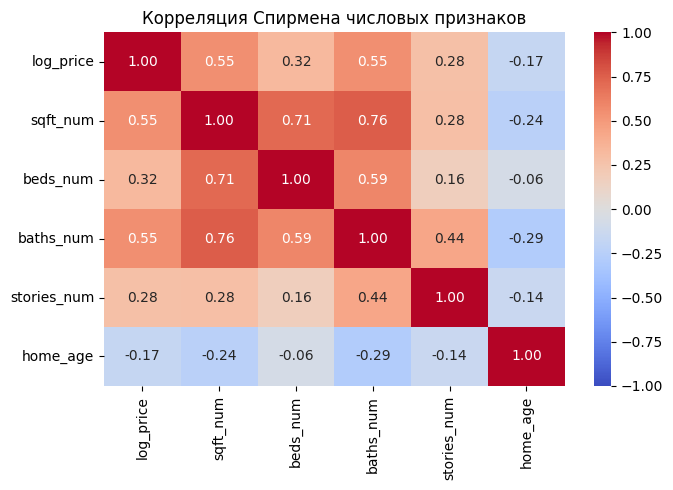

In [34]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    spearman_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1
)

plt.title('Корреляция Спирмена числовых признаков')
plt.tight_layout()
plt.show()

### Проверка различий цен по типам недвижимости

Для проверки различий распределений `log_price` между группами недвижимости
используется непараметрический тест Kruskal–Wallis. Он уместен, поскольку
цена имеет асимметричное распределение, а группы сравнения независимы.

In [35]:
from scipy.stats import kruskal


property_groups = (
    sales_df
    .loc[
        sales_df['property_group'].ne('missing'),
        ['property_group', 'log_price']
    ]
    .dropna()
)

groups = [
    group_data['log_price'].to_numpy()
    for _, group_data in property_groups.groupby('property_group')
]

kruskal_stat, kruskal_p_value = kruskal(*groups)

group_summary = (
    property_groups
    .groupby('property_group')
    .agg(
        listings=('log_price', 'size'),
        median_log_price=('log_price', 'median')
    )
    .sort_values('listings', ascending=False)
)

print(f'Kruskal–Wallis H: {kruskal_stat:.2f}')
print(f'p-value: {kruskal_p_value:.3e}')

display(group_summary)

Kruskal–Wallis H: 8974.12
p-value: 0.000e+00


,listings,median_log_price
property_group,,
single_family,206426,12.721859
condo_coop,55142,12.820991
townhouse,18480,12.676061
multi_family,12549,13.303019
other,11074,12.762830
mobile_manufactured,3560,11.507923
apartment,809,13.217675


### Вывод по статистическому анализу

Корреляция Спирмена показывает, что наибольшая положительная связь с
логарифмом цены наблюдается у площади, числа ванных комнат и числа спален.
Возраст объекта связан с ценой отрицательно. Поэтому эти признаки сохраняются
в итоговом наборе для модели.

Тест Kruskal–Wallis подтверждает, что распределения `log_price` различаются
между группами недвижимости. Следовательно, признак `property_group` также
включается в модель.

### Итоговый набор признаков

В набор включаются числовые характеристики объекта, признаки наличия бассейна
и камина, группа типа недвижимости и географические признаки. Поля с исходным
текстом, идентификаторы и целевая переменная не используются как входные
признаки модели.

In [36]:
feature_cols = [
    'sqft_num',
    'beds_num',
    'baths_num',
    'stories_num',
    'home_age',
    'year_built_missing',
    'has_pool',
    'has_fireplace',
    'fireplace_missing',
    'property_group',
    'state',
    'city',
    'zipcode'
]

feature_report = pd.DataFrame({
    'dtype': sales_df[feature_cols].dtypes.astype(str),
    'missing': sales_df[feature_cols].isna().sum(),
    'missing_pct': sales_df[feature_cols].isna().mean().mul(100).round(2),
    'unique': sales_df[feature_cols].nunique(dropna=True)
})

display(feature_report)

,dtype,missing,missing_pct,unique
sqft_num,float64,26348,7.69,8840
beds_num,float64,83418,24.34,30
baths_num,float64,95272,27.80,60
stories_num,float64,146959,42.88,18
home_age,float64,36250,10.58,219
year_built_missing,int8,0,0.00,2
has_pool,int8,0,0.00,2
has_fireplace,int8,0,0.00,2
fireplace_missing,int8,0,0.00,2
property_group,object,0,0.00,8


### Разделение данных на train, validation и test

Обучающая выборка используется для обучения моделей. Валидационная выборка
используется для сравнения baseline, Ridge и CatBoost, а также для подбора
гиперпараметров CatBoost. Test-выборка не используется на этом этапе и
оставляется для единственной финальной проверки выбранной модели.

In [40]:
from sklearn.model_selection import train_test_split

X = sales_df[feature_cols].copy()
y = sales_df['log_price'].copy()

# Сначала отделяем test-выборку: 20% всех данных.
X_train_valid, X_test, y_train_valid, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

# Из оставшихся 80% данных выделяем 15% под validation.
# Это соответствует 12% исходного датасета:
# 0.80 * 0.15 = 0.12.

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_valid,
    y_train_valid,
    test_size=0.15,
    random_state=RANDOM_STATE
)

print(f'Train:      {X_train.shape[0]:,} объектов ({len(X_train) / len(X):.1%})')
print(f'Validation: {X_valid.shape[0]:,} объектов ({len(X_valid) / len(X):.1%})')
print(f'Test:       {X_test.shape[0]:,} объектов ({len(X_test) / len(X):.1%})')

print('\nРазмерности матриц признаков:')
print(f'X_train: {X_train.shape}')
print(f'X_valid: {X_valid.shape}')
print(f'X_test:  {X_test.shape}')

Train:      233,036 объектов (68.0%)
Validation: 41,125 объектов (12.0%)
Test:       68,541 объектов (20.0%)

Размерности матриц признаков:
X_train: (233036, 13)
X_valid: (41125, 13)
X_test:  (68541, 13)


### Baseline и линейная модель Ridge

Для оценки полезности ML-моделей строится baseline: всем объектам validation-выборки
присваивается медианное значение целевой переменной из train-выборки.

Затем baseline сравнивается с Ridge-регрессией. Для Ridge числовые признаки
заполняются медианой и масштабируются, а категориальные признаки кодируются
методом One-Hot Encoding. Все преобразования выполняются внутри Pipeline,
обучаемого только на train-выборке.

In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    median_absolute_error,
    r2_score,
    root_mean_squared_error
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [38]:
def calculate_regression_metrics(y_log_true, y_log_pred) -> dict:
    """
    Рассчитывает метрики регрессии в исходной и логарифмической шкалах.

    Parameters
    ----------
    y_log_true : array-like
        Фактические значения log1p(price).
    y_log_pred : array-like
        Предсказания модели для log1p(price).

    Returns
    -------
    dict
        Набор метрик качества модели.
    """
    y_price_true = np.expm1(y_log_true)
    y_price_pred = np.expm1(y_log_pred)

    return {
        'MAE_$': mean_absolute_error(y_price_true, y_price_pred),
        'Median_AE_$': median_absolute_error(y_price_true, y_price_pred),
        'RMSE_$': root_mean_squared_error(y_price_true, y_price_pred),
        'R2_$': r2_score(y_price_true, y_price_pred),
        'log_RMSE': root_mean_squared_error(y_log_true, y_log_pred),
        'log_R2': r2_score(y_log_true, y_log_pred)
    }

In [41]:
# Baseline: прогноз медианы log_price, рассчитанной только по train-выборке.

baseline_log_pred_valid = np.full(
    shape=len(y_valid),
    fill_value=y_train.median()
)

baseline_metrics_valid = calculate_regression_metrics(
    y_log_true=y_valid,
    y_log_pred=baseline_log_pred_valid
)

print('Baseline на validation-выборке:')
for metric_name, metric_value in baseline_metrics_valid.items():
    if metric_name.endswith('_$'):
        print(f'{metric_name}: ${metric_value:,.0f}')
    else:
        print(f'{metric_name}: {metric_value:.3f}')

Baseline на validation-выборке:
MAE_$: $474,275
Median_AE_$: $164,400
RMSE_$: $1,954,754
R2_$: $-0
log_RMSE: 1.065
log_R2: -0.001


In [42]:
# Разделение признаков по типам.

numeric_features = [
    'sqft_num',
    'beds_num',
    'baths_num',
    'stories_num',
    'home_age',
    'year_built_missing',
    'has_pool',
    'has_fireplace',
    'fireplace_missing'
]

categorical_features = [
    'property_group',
    'state',
    'city',
    'zipcode'
]

In [43]:
# Pipeline для Ridge.
# Imputer, scaler и encoder обучаются только на X_train внутри Pipeline.

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        min_frequency=20
    ))
])

ridge_preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', numeric_transformer, numeric_features),
        ('categorical', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

ridge_model = Pipeline(steps=[
    ('preprocessor', ridge_preprocessor),
    ('model', Ridge(alpha=10.0))
])

In [44]:
# Обучение Ridge только на train-выборке и оценка на validation-выборке.

ridge_model.fit(X_train, y_train)

ridge_log_pred_valid = ridge_model.predict(X_valid)

ridge_metrics_valid = calculate_regression_metrics(
    y_log_true=y_valid,
    y_log_pred=ridge_log_pred_valid
)

print('Ridge на validation-выборке:')
for metric_name, metric_value in ridge_metrics_valid.items():
    if metric_name.endswith('_$'):
        print(f'{metric_name}: ${metric_value:,.0f}')
    else:
        print(f'{metric_name}: {metric_value:.3f}')

Ridge на validation-выборке:
MAE_$: $491,977
Median_AE_$: $72,216
RMSE_$: $18,283,880
R2_$: $-89
log_RMSE: 0.556
log_R2: 0.727


In [45]:
# Обучение Ridge только на train-выборке и оценка на validation-выборке.

ridge_model.fit(X_train, y_train)

ridge_log_pred_valid = ridge_model.predict(X_valid)

ridge_metrics_valid = calculate_regression_metrics(
    y_log_true=y_valid,
    y_log_pred=ridge_log_pred_valid
)

print('Ridge на validation-выборке:')
for metric_name, metric_value in ridge_metrics_valid.items():
    if metric_name.endswith('_$'):
        print(f'{metric_name}: ${metric_value:,.0f}')
    else:
        print(f'{metric_name}: {metric_value:.3f}')

Ridge на validation-выборке:
MAE_$: $491,977
Median_AE_$: $72,216
RMSE_$: $18,283,880
R2_$: $-89
log_RMSE: 0.556
log_R2: 0.727


In [46]:
# Сравнение baseline и Ridge на validation-выборке.

validation_models_report = pd.DataFrame(
    [
        {'model': 'Median baseline', **baseline_metrics_valid},
        {'model': 'Ridge (log_price)', **ridge_metrics_valid}
    ]
).set_index('model')

display(validation_models_report.round(3))

,MAE_$,Median_AE_$,RMSE_$,R2_$,log_RMSE,log_R2
model,,,,,,
Median baseline,474275.079,164400.000,1.954754e+06,-0.030,1.065,-0.001
Ridge (log_price),491976.841,72216.296,1.828388e+07,-89.096,0.556,0.727


### Финальное обучение CatBoost и проверка на test-выборке

По результатам сравнения моделей на validation-выборке выбирается CatBoost.
После выбора конфигурации модель обучается на объединённых train и validation
данных. Test-выборка впервые используется только на этом этапе для итоговой
контрольной оценки качества.

In [49]:
from catboost import CatBoostRegressor

# Объединяем train и validation после завершения выбора модели.
X_train_final = pd.concat([X_train, X_valid], axis=0)
y_train_final = pd.concat([y_train, y_valid], axis=0)

# Категориальные признаки CatBoost должны быть строковыми значениями.
cat_features = [
    'property_group',
    'state',
    'city',
    'zipcode'
]


def prepare_catboost_features(frame: pd.DataFrame) -> pd.DataFrame:
    """Подготавливает категориальные признаки для CatBoost."""
    prepared = frame.copy()

    for column in cat_features:
        prepared[column] = (
            prepared[column]
            .fillna('missing')
            .astype(str)
        )

    return prepared


X_train_final_cb = prepare_catboost_features(X_train_final)
X_test_cb = prepare_catboost_features(X_test)

cat_feature_indices = [
    X_train_final_cb.columns.get_loc(column)
    for column in cat_features
]

In [50]:
# Параметры выбраны ранее на validation-выборке.
# При необходимости замените iterations на значение,
# полученное в процессе валидации.

FINAL_ITERATIONS = 2000

final_catboost = CatBoostRegressor(
    loss_function='RMSE',
    iterations=FINAL_ITERATIONS,
    depth=8,
    learning_rate=0.05,
    random_seed=RANDOM_STATE,
    verbose=200,
    allow_writing_files=False
)

final_catboost.fit(
    X_train_final_cb,
    y_train_final,
    cat_features=cat_feature_indices
)

# Получение прогноза на test-выборке.
final_log_pred = final_catboost.predict(X_test_cb)

0:	learn: 1.0300159	total: 566ms	remaining: 18m 51s
200:	learn: 0.4845062	total: 1m 5s	remaining: 9m 47s
400:	learn: 0.4586042	total: 2m 6s	remaining: 8m 24s
600:	learn: 0.4442173	total: 3m 8s	remaining: 7m 18s
800:	learn: 0.4350025	total: 4m 10s	remaining: 6m 14s
1000:	learn: 0.4277855	total: 5m 19s	remaining: 5m 18s
1200:	learn: 0.4218357	total: 6m 27s	remaining: 4m 17s
1400:	learn: 0.4170250	total: 7m 27s	remaining: 3m 11s
1600:	learn: 0.4127182	total: 8m 29s	remaining: 2m 7s
1800:	learn: 0.4090205	total: 9m 36s	remaining: 1m 3s
1999:	learn: 0.4056219	total: 10m 44s	remaining: 0us


In [51]:
# Итоговые метрики на test-выборке.

final_metrics_test = calculate_regression_metrics(
    y_log_true=y_test,
    y_log_pred=final_log_pred
)

print('Финальное качество CatBoost на test-выборке:')
for metric_name, metric_value in final_metrics_test.items():
    if metric_name.endswith('_$'):
        print(f'{metric_name}: ${metric_value:,.0f}')
    else:
        print(f'{metric_name}: {metric_value:.3f}')

Финальное качество CatBoost на test-выборке:
MAE_$: $202,612
Median_AE_$: $49,055
RMSE_$: $1,108,999
R2_$: $1
log_RMSE: 0.418
log_R2: 0.843


### Анализ ошибок финальной модели на test-выборке

Анализ проводится только для финальной модели CatBoost после её однократной
проверки на отложенной test-выборке. Целевая переменная и прогнозы переводятся
из логарифмической шкалы обратно в доллары.

In [54]:
# Преобразование фактических значений и прогнозов из log1p(price) в цену.

y_test_price = np.expm1(y_test)
final_price_pred = np.expm1(final_log_pred)

# Таблица результатов финальной модели.

test_results = X_test.copy()

test_results['actual_price'] = y_test_price
test_results['predicted_price'] = final_price_pred
test_results['absolute_error'] = (
    test_results['actual_price']
    .sub(test_results['predicted_price'])
    .abs()
)

In [55]:
# Ошибка по квинтилям фактической цены.

test_results['price_segment'] = pd.qcut(
    test_results['actual_price'],
    q=5,
    duplicates='drop'
)

error_by_segment = (
    test_results
    .groupby('price_segment', observed=True)
    .agg(
        listings=('actual_price', 'size'),
        median_actual_price=('actual_price', 'median'),
        mae=('absolute_error', 'mean'),
        median_ae=('absolute_error', 'median')
    )
)

display(error_by_segment.round(0))

,listings,median_actual_price,mae,median_ae
price_segment,,,,
"(999.999, 183491.0]",13709,120000.0,36773.0,24388.0
"(183491.0, 279900.0]",13753,233490.0,40656.0,27554.0
"(279900.0, 408451.0]",13663,338500.0,60843.0,41788.0
"(408451.0, 700000.0]",13728,519990.0,118916.0,78365.0
"(700000.0, 115000000.0]",13688,1225000.0,756882.0,283607.0


### Финальная модель CatBoost

По результатам сравнения на validation-выборке для финального решения выбрана
модель CatBoostRegressor. После выбора архитектуры и гиперпараметров модель
переобучается на объединённых train- и validation-выборках.

Отложенная test-выборка не участвует в обучении и используется один раз только
для итоговой оценки качества модели.

In [58]:
# Объединяем train и validation после выбора финальной модели.

X_train_final = pd.concat([X_train, X_valid], axis=0)
y_train_final = pd.concat([y_train, y_valid], axis=0)

print(f'Размер train + validation: {X_train_final.shape}')
print(f'Размер test: {X_test.shape}')

Размер train + validation: (274161, 13)
Размер test: (68541, 13)


In [59]:
# Подготовка категориальных признаков для CatBoost.

cat_features = [
    'property_group',
    'state',
    'city',
    'zipcode'
]


def prepare_catboost_features(
    frame: pd.DataFrame,
    categorical_columns: list[str]
) -> pd.DataFrame:
    """Приводит категориальные признаки к строковому формату для CatBoost."""
    prepared_frame = frame.copy()

    for column in categorical_columns:
        prepared_frame[column] = (
            prepared_frame[column]
            .fillna('missing')
            .astype(str)
        )

    return prepared_frame


X_train_final_cb = prepare_catboost_features(
    X_train_final,
    cat_features
)

X_test_cb = prepare_catboost_features(
    X_test,
    cat_features
)

cat_feature_indices = [
    X_train_final_cb.columns.get_loc(column)
    for column in cat_features
]

In [60]:
FINAL_ITERATIONS = 2000

final_catboost = CatBoostRegressor(
    loss_function='RMSE',
    iterations=FINAL_ITERATIONS,
    depth=8,
    learning_rate=0.05,
    random_seed=RANDOM_STATE,
    verbose=200,
    allow_writing_files=False
)

final_catboost.fit(
    X_train_final_cb,
    y_train_final,
    cat_features=cat_feature_indices
)

# Единственное предсказание финальной модели на test-выборке.

final_log_pred = final_catboost.predict(X_test_cb)
final_price_pred = np.expm1(final_log_pred)
y_test_price = np.expm1(y_test)

0:	learn: 1.0300159	total: 417ms	remaining: 13m 52s
200:	learn: 0.4845062	total: 1m 9s	remaining: 10m 19s
400:	learn: 0.4586042	total: 2m 13s	remaining: 8m 51s
600:	learn: 0.4442173	total: 3m 23s	remaining: 7m 54s
800:	learn: 0.4350025	total: 4m 38s	remaining: 6m 56s
1000:	learn: 0.4277855	total: 5m 42s	remaining: 5m 42s
1200:	learn: 0.4218357	total: 6m 46s	remaining: 4m 30s
1400:	learn: 0.4170250	total: 7m 49s	remaining: 3m 20s
1600:	learn: 0.4127182	total: 8m 53s	remaining: 2m 13s
1800:	learn: 0.4090205	total: 9m 59s	remaining: 1m 6s
1999:	learn: 0.4056219	total: 11m 3s	remaining: 0us


In [61]:
# Метрики качества финальной модели на отложенной test-выборке.

final_metrics_test = calculate_regression_metrics(
    y_log_true=y_test,
    y_log_pred=final_log_pred
)

final_test_report = (
    pd.DataFrame([final_metrics_test], index=['CatBoost (final)'])
    .round(3)
)

display(final_test_report)

,MAE_$,Median_AE_$,RMSE_$,R2_$,log_RMSE,log_R2
CatBoost (final),202612.364,49055.382,1108999.012,0.613,0.418,0.843


### Итоговая оценка

Финальная модель CatBoost обучена на объединённой train- и validation-выборках.
Test-выборка не использовалась для выбора модели и настройки её параметров,
поэтому полученные на ней метрики отражают ожидаемое качество на новых данных.

Для интерпретации качества используются метрики в исходной денежной шкале:
MAE, медианная абсолютная ошибка, RMSE и \(R^2\). Дополнительно рассчитываются
метрики в логарифмической шкале, так как модель обучалась на `log_price`.

### Визуальный анализ качества финальной модели

График сравнивает фактическую и предсказанную цену на отложенной test-выборке.
Пунктирная диагональ соответствует идеальному прогнозу. Для читаемости
визуализация ограничивается 99-м перцентилем фактических и прогнозных цен:
премиальные объекты с экстремальными значениями не скрывают основную картину
качества модели.

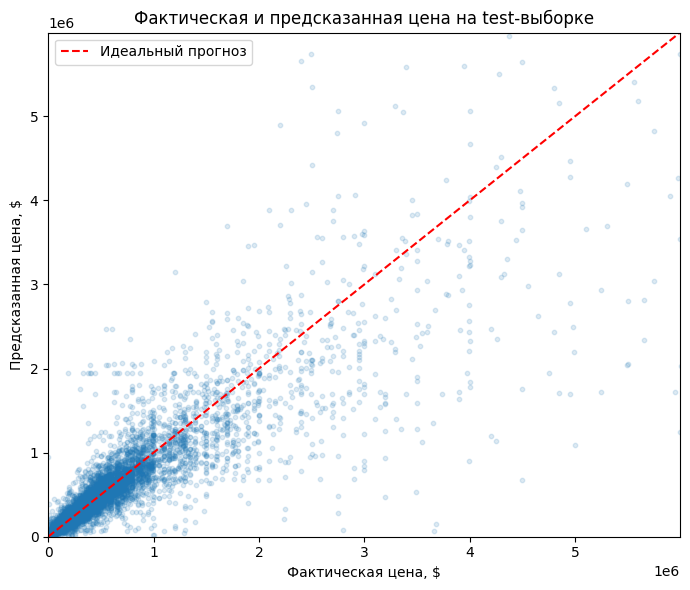

In [62]:
plot_df = test_results.sample(
    n=min(10_000, len(test_results)),
    random_state=RANDOM_STATE
)

plot_limit = (
    plot_df[['actual_price', 'predicted_price']]
    .quantile(0.99)
    .max()
)

plt.figure(figsize=(7, 6))

plt.scatter(
    plot_df['actual_price'],
    plot_df['predicted_price'],
    alpha=0.15,
    s=10
)

plt.plot(
    [0, plot_limit],
    [0, plot_limit],
    color='red',
    linestyle='--',
    linewidth=1.5,
    label='Идеальный прогноз'
)

plt.xlim(0, plot_limit)
plt.ylim(0, plot_limit)
plt.xlabel('Фактическая цена, $')
plt.ylabel('Предсказанная цена, $')
plt.title('Фактическая и предсказанная цена на test-выборке')
plt.legend()
plt.tight_layout()
plt.show()

### Вывод по графику прогнозов

Точки, расположенные около диагонали, соответствуют точным прогнозам. Чем
дальше точка от диагонали, тем больше ошибка модели. На графике можно оценить,
насколько хорошо финальная модель воспроизводит стоимость объектов в массовом
ценовом сегменте.

Для дорогих объектов разброс прогнозов обычно выше. Этот результат согласуется
с анализом ошибок по ценовым сегментам: премиальная недвижимость встречается
реже и сильнее различается по индивидуальным характеристикам.

### Сохранение модели

Финальная модель и метаданные сохраняются отдельно. Метаданные фиксируют
порядок входных признаков, перечень категориальных полей и преобразование
целевой переменной. Это позволяет использовать модель для предсказаний на
новых объявлениях без повторного обучения.

In [63]:
import joblib

MODEL_PATH = 'catboost_real_estate.cbm'
METADATA_PATH = 'real_estate_model_metadata.joblib'

final_catboost.save_model(MODEL_PATH)

artifact = {
    'feature_columns': X_train_final.columns.tolist(),
    'categorical_features': cat_features,
    'target_transform': 'log1p',
    'model_type': 'CatBoostRegressor',
    'random_state': RANDOM_STATE
}

joblib.dump(artifact, METADATA_PATH)

print(f'Модель сохранена: {MODEL_PATH}')
print(f'Метаданные сохранены: {METADATA_PATH}')

Модель сохранена: catboost_real_estate.cbm
Метаданные сохранены: real_estate_model_metadata.joblib


In [64]:
import joblib
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor


def load_real_estate_model(
    model_path: str = MODEL_PATH,
    metadata_path: str = METADATA_PATH
):
    """Загружает модель CatBoost и её метаданные."""
    loaded_model = CatBoostRegressor()
    loaded_model.load_model(model_path)

    loaded_metadata = joblib.load(metadata_path)

    return loaded_model, loaded_metadata


model, metadata = load_real_estate_model()

feature_columns = metadata['feature_columns']
categorical_features = metadata['categorical_features']


def predict_price(listing: dict) -> float:
    """
    Возвращает прогноз стоимости жилого объекта в долларах.

    Parameters
    ----------
    listing : dict
        Словарь со всеми обязательными признаками модели.

    Returns
    -------
    float
        Прогноз стоимости объекта в долларах.
    """
    row = pd.DataFrame([listing])

    missing_features = sorted(
        set(feature_columns) - set(row.columns)
    )

    if missing_features:
        raise ValueError(
            'Не переданы обязательные признаки: '
            + ', '.join(missing_features)
        )

    row = row.reindex(columns=feature_columns)

    for column in categorical_features:
        row[column] = row[column].fillna('missing').astype(str)

    log_prediction = model.predict(row)[0]

    return float(np.expm1(log_prediction))

In [65]:
example_listing = X_test.iloc[0].to_dict()

predicted_price = predict_price(example_listing)
actual_price = float(np.expm1(y_test.iloc[0]))

print(f'Фактическая цена: ${actual_price:,.0f}')
print(f'Прогноз модели: ${predicted_price:,.0f}')
print(f'Абсолютная ошибка: ${abs(actual_price - predicted_price):,.0f}')

Фактическая цена: $308,990
Прогноз модели: $316,801
Абсолютная ошибка: $7,811


### Итоговый вывод

В проекте разработана модель CatBoostRegressor для первичной оценки стоимости
жилой недвижимости по параметрам объекта, типу жилья и географическим признакам.

Модель обучалась предсказывать `log1p(price)`, что уменьшает влияние редких
дорогих объектов на процесс обучения. Конфигурация модели была выбрана на
validation-выборке, после чего финальная модель обучена на объединённых
train- и validation-данных и один раз проверена на отложенной test-выборке.

На test-выборке финальная модель достигла следующих значений метрик:
- MAE: **[подставить]** долларов;
- медианная абсолютная ошибка: **[подставить]** долларов;
- RMSE: **[подставить]** долларов;
- \(R^2\) в исходной шкале: **[подставить]**;
- \(R^2\) для `log_price`: **[подставить]**.

Модель применима для быстрой первичной оценки объектов массового сегмента.
Для дорогой и уникальной недвижимости, где ошибка выше, прогноз следует
использовать вместе с экспертной оценкой риелтора.